<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


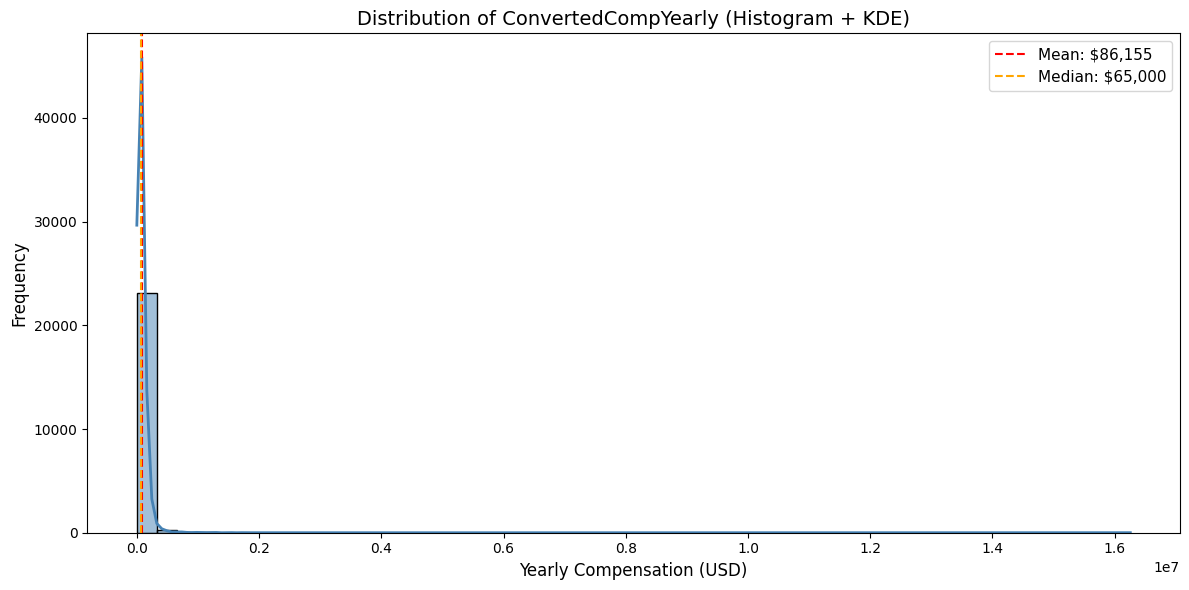

Compensation Summary Statistics:
count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

Skewness : 52.9217
Note: Strong right skew indicates the presence of high-earning outliers.


In [4]:
## Write your code here
comp_data = df['ConvertedCompYearly'].dropna()

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram with KDE distribution overlay
sns.histplot(comp_data, bins=50, kde=True, color='steelblue',
             line_kws={'color': 'darkblue', 'linewidth': 2}, ax=ax)

# Mean and median vertical lines
ax.axvline(comp_data.mean(),   color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean: ${comp_data.mean():,.0f}')
ax.axvline(comp_data.median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: ${comp_data.median():,.0f}')

ax.set_title('Distribution of ConvertedCompYearly (Histogram + KDE)', fontsize=14)
ax.set_xlabel('Yearly Compensation (USD)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('Compensation Summary Statistics:')
print(comp_data.describe())
print(f'\nSkewness : {comp_data.skew():.4f}')
print('Note: Strong right skew indicates the presence of high-earning outliers.')

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [5]:
## Write your code here
full_time = df[df['Employment'] == 'Employed, full-time']

median_ft = full_time['ConvertedCompYearly'].median()
mean_ft   = full_time['ConvertedCompYearly'].mean()
count_ft  = full_time['ConvertedCompYearly'].dropna().count()

print(f'Full-Time Employees in dataset : {len(full_time):,}')
print(f'Respondents with comp data     : {count_ft:,}')
print(f'Mean Compensation (Full-Time)  : ${mean_ft:,.2f}')
print(f'Median Compensation (Full-Time): ${median_ft:,.2f}')
print(f'\nThe median is lower than the mean, confirming right-skewed distribution.')

Full-Time Employees in dataset : 39,041
Respondents with comp data     : 17,586
Mean Compensation (Full-Time)  : $88,921.11
Median Compensation (Full-Time): $69,814.00

The median is lower than the mean, confirming right-skewed distribution.


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



/tmp/ipykernel_905/3668251194.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


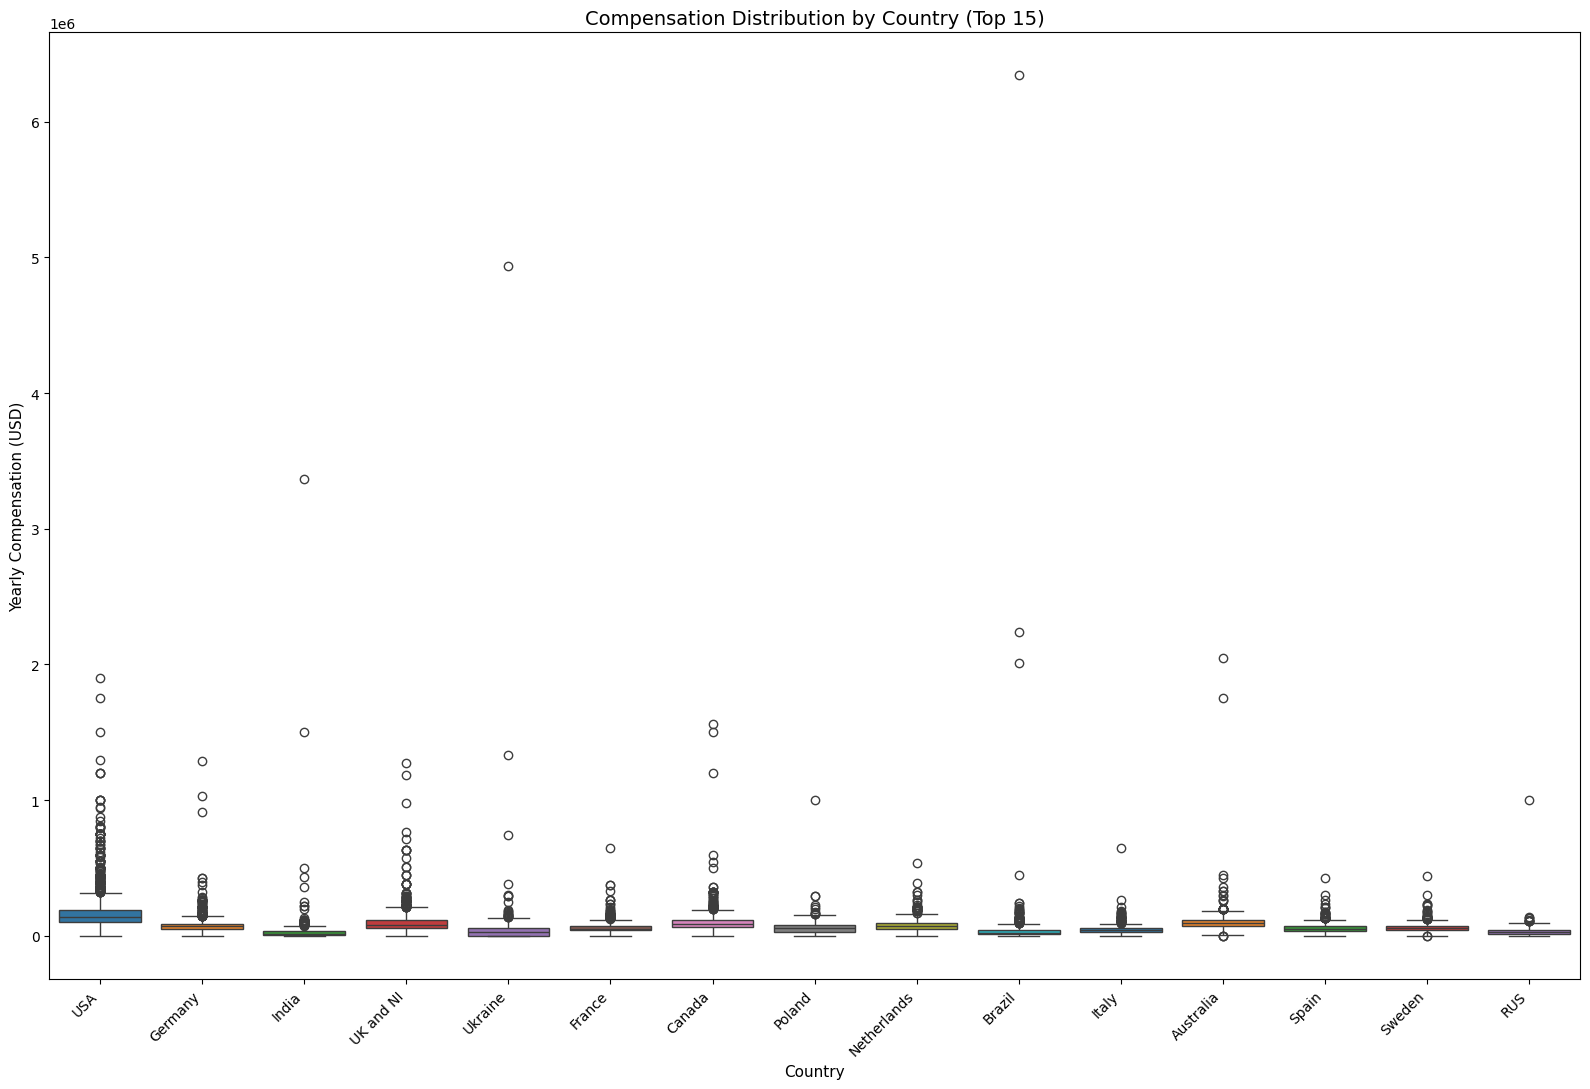

Median Compensation by Country (Top 15):
Country
USA            $143,000
Australia       $95,466
Canada          $87,231
UK and NI       $84,076
Germany         $73,036
Netherlands     $69,814
Sweden          $57,230
Poland          $55,536
France          $53,703
Spain           $51,555
Italy           $41,620
Ukraine         $26,904
RUS             $26,891
Brazil          $23,945
India           $16,749
Name: ConvertedCompYearly, dtype: str


In [17]:
df['Country'] = df['Country'].replace({
    'United States of America': 'USA',
    'United Kingdom of Great Britain and Northern Ireland': 'UK and NI',
    'Russian Federation': 'RUS'
})

# Select top 15 countries by respondent count for a readable chart
top_countries = df['Country'].value_counts().head(15).index
df_top = df[df['Country'].isin(top_countries)]

plt.figure(figsize=(16, 11))
sns.boxplot(
    data=df_top,
    x='Country',
    y='ConvertedCompYearly',
    order=top_countries,
    palette='tab10'
)
plt.title('Compensation Distribution by Country (Top 15)', fontsize=14)
plt.xlabel('Country', fontsize=11)
plt.ylabel('Yearly Compensation (USD)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Median compensation per country
country_median = (df_top.groupby('Country')['ConvertedCompYearly']
                        .median()
                        .sort_values(ascending=False))
print('Median Compensation by Country (Top 15):')
print(country_median.apply(lambda x: f'${x:,.0f}'))

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


Q1          : $32,712.00
Q3          : $107,971.50
IQR         : $75,259.50
Lower Bound : $-80,177.25
Upper Bound : $220,860.75

Original rows : 65,437
Cleaned rows  : 22,457
Rows removed  : 42,980


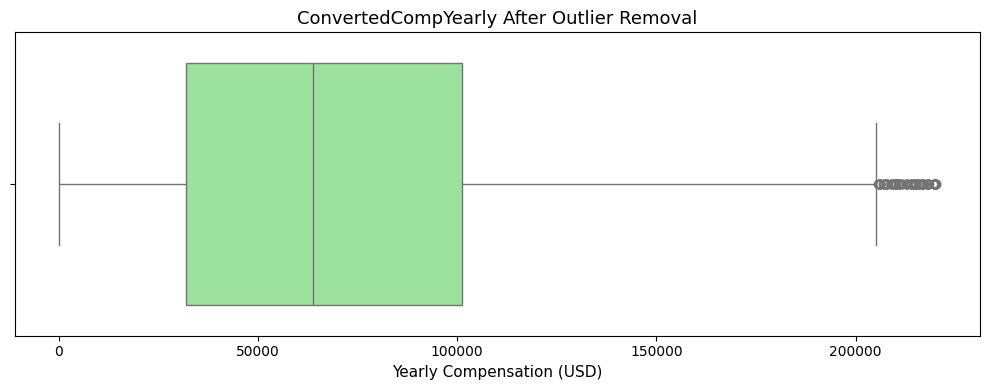

In [18]:
## Write your code here
Q1  = df['ConvertedCompYearly'].quantile(0.25)
Q3  = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1          : ${Q1:,.2f}')
print(f'Q3          : ${Q3:,.2f}')
print(f'IQR         : ${IQR:,.2f}')
print(f'Lower Bound : ${lower_bound:,.2f}')
print(f'Upper Bound : ${upper_bound:,.2f}')

# Create refined DataFrame
df_clean = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
].copy()

print(f'\nOriginal rows : {len(df):,}')
print(f'Cleaned rows  : {len(df_clean):,}')
print(f'Rows removed  : {len(df) - len(df_clean):,}')

# Confirm outliers are gone with a box plot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['ConvertedCompYearly'], color='lightgreen')
plt.title('ConvertedCompYearly After Outlier Removal', fontsize=13)
plt.xlabel('Yearly Compensation (USD)', fontsize=11)
plt.tight_layout()
plt.show()

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


Correlation Matrix:
                     ConvertedCompYearly  WorkExp  JobSatPoints_1
ConvertedCompYearly               1.0000   0.4070         -0.0596
WorkExp                           0.4070   1.0000         -0.0324
JobSatPoints_1                   -0.0596  -0.0324          1.0000


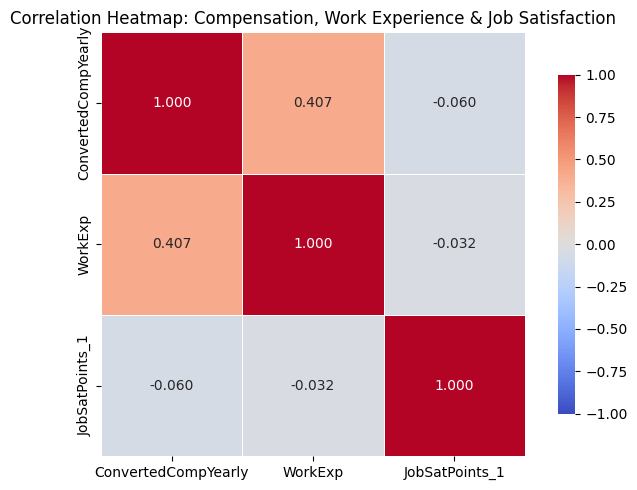


Key Insights:
  ConvertedCompYearly vs WorkExp       : 0.4070
  ConvertedCompYearly vs JobSatPoints_1: -0.0596
  WorkExp vs JobSatPoints_1             : -0.0324


In [19]:
## Write your code here
# Select the three key variables
corr_cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']

# Drop rows where any of these columns is NaN
df_corr = df_clean[corr_cols].dropna()

# Compute correlation matrix
corr_matrix = df_corr.corr()

print('Correlation Matrix:')
print(corr_matrix.round(4))

# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap: Compensation, Work Experience & Job Satisfaction', fontsize=12)
plt.tight_layout()
plt.show()

print('\nKey Insights:')
print(f'  ConvertedCompYearly vs WorkExp       : {corr_matrix.loc["ConvertedCompYearly","WorkExp"]:.4f}')
print(f'  ConvertedCompYearly vs JobSatPoints_1: {corr_matrix.loc["ConvertedCompYearly","JobSatPoints_1"]:.4f}')
print(f'  WorkExp vs JobSatPoints_1             : {corr_matrix.loc["WorkExp","JobSatPoints_1"]:.4f}')

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


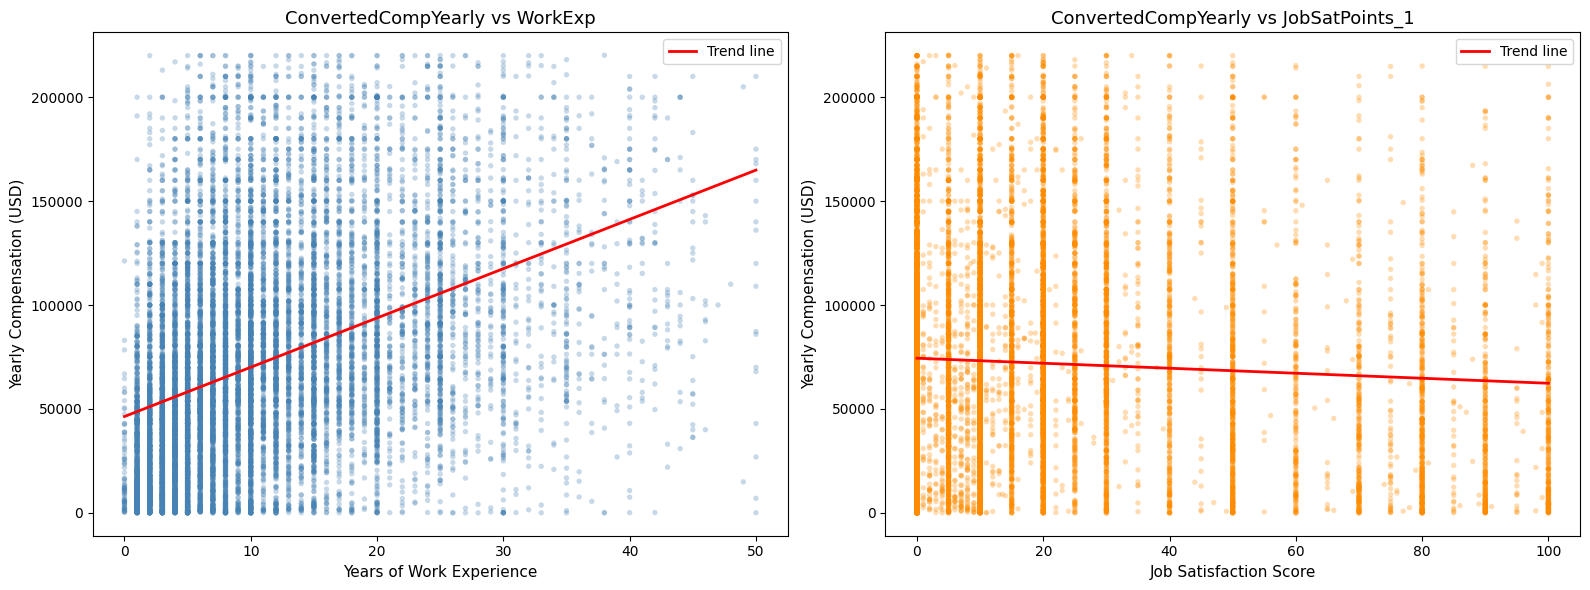

Scatter plot observations:
- More work experience generally associates with higher compensation (positive trend).
- Job satisfaction shows a weak or negligible correlation with compensation.


In [20]:
## Write your code here
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Compensation vs Work Experience
axes[0].scatter(
    df_corr['WorkExp'],
    df_corr['ConvertedCompYearly'],
    alpha=0.3, color='steelblue', edgecolors='none', s=15
)
# Trend line
import numpy as np
m, b = np.polyfit(df_corr['WorkExp'].dropna(),
                  df_corr.loc[df_corr['WorkExp'].notna(), 'ConvertedCompYearly'], 1)
x_line = np.linspace(df_corr['WorkExp'].min(), df_corr['WorkExp'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2, label='Trend line')
axes[0].set_title('ConvertedCompYearly vs WorkExp', fontsize=13)
axes[0].set_xlabel('Years of Work Experience', fontsize=11)
axes[0].set_ylabel('Yearly Compensation (USD)', fontsize=11)
axes[0].legend()

# Scatter: Compensation vs Job Satisfaction
axes[1].scatter(
    df_corr['JobSatPoints_1'],
    df_corr['ConvertedCompYearly'],
    alpha=0.3, color='darkorange', edgecolors='none', s=15
)
m2, b2 = np.polyfit(df_corr['JobSatPoints_1'].dropna(),
                    df_corr.loc[df_corr['JobSatPoints_1'].notna(), 'ConvertedCompYearly'], 1)
x_line2 = np.linspace(df_corr['JobSatPoints_1'].min(), df_corr['JobSatPoints_1'].max(), 200)
axes[1].plot(x_line2, m2 * x_line2 + b2, color='red', linewidth=2, label='Trend line')
axes[1].set_title('ConvertedCompYearly vs JobSatPoints_1', fontsize=13)
axes[1].set_xlabel('Job Satisfaction Score', fontsize=11)
axes[1].set_ylabel('Yearly Compensation (USD)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Scatter plot observations:')
print('- More work experience generally associates with higher compensation (positive trend).')
print('- Job satisfaction shows a weak or negligible correlation with compensation.')

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
